## Data Visualizations

In [6]:
import pandas as pd

df = pd.read_csv("../data/startup_success_dataset.csv")

In [27]:
# Simple numerical comparison by outcome
num_cols = [
    "funding_rounds",
    "founder_experience_years",
    "team_size",
    "market_size_billion",
    "product_traction_users",
    "burn_rate_million",
    "revenue_million"
]

df.groupby("outcome")[num_cols].mean().round(2)

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
outcome,,,,,,,
Acquisition,2.35,13.53,159.24,33.38,350871.97,16.83,1041604.00
Failure,1.70,10.75,143.46,33.08,225905.48,16.72,536378.93
IPO,3.00,15.54,172.09,32.82,547695.59,17.22,2120475.26


We compute the average values of numerical features across each startup outcome to identify differences between failed, acquired, and IPO companies.

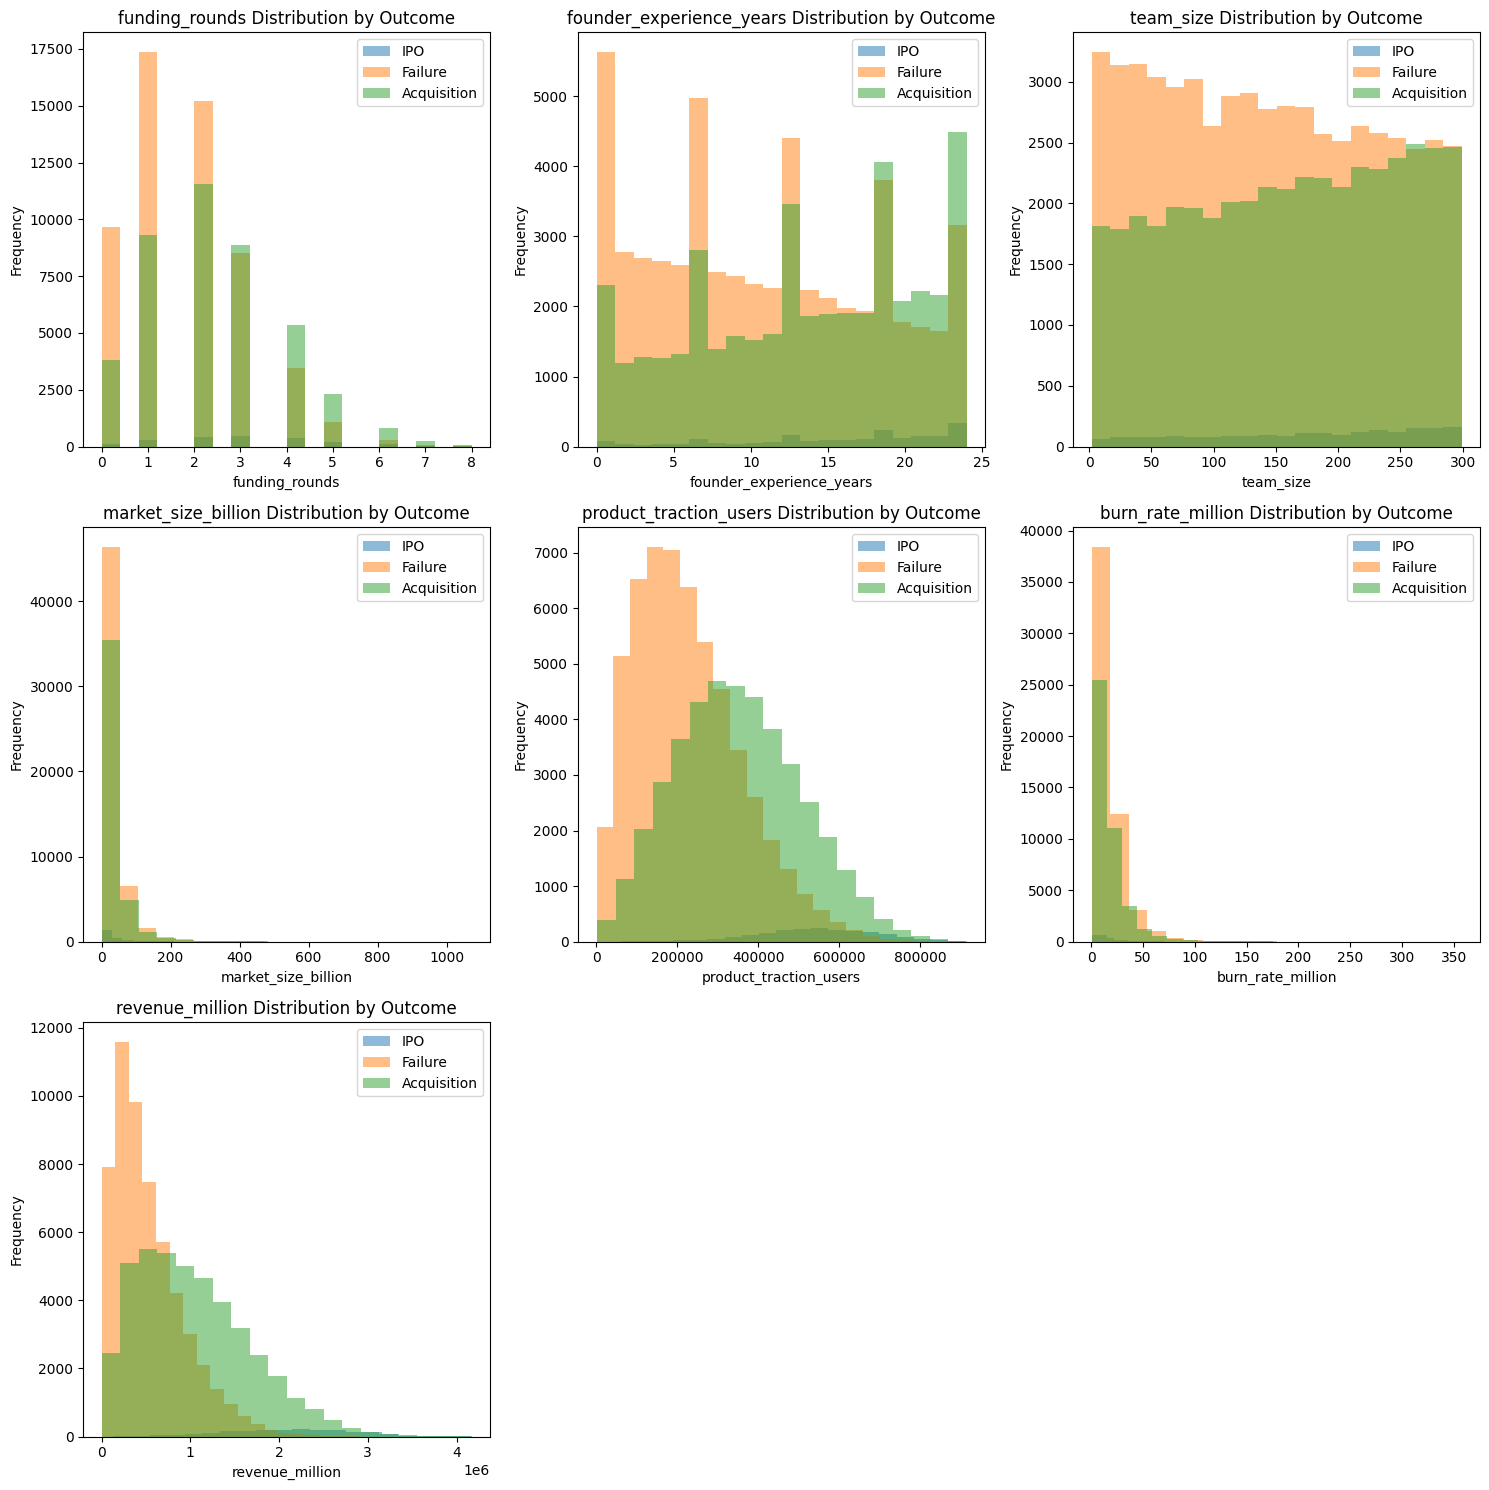

In [25]:
import matplotlib.pyplot as plt

num_cols = [
    "funding_rounds",
    "founder_experience_years",
    "team_size",
    "market_size_billion",
    "product_traction_users",
    "burn_rate_million",
    "revenue_million"
]

# Number of rows and columns for subplots
n_cols = 3  # 3 columns per row
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # Number of rows needed

plt.figure(figsize=(15, 5 * n_rows))

# Loop through the features and plot them
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)  # Specify row/column grid
    for outcome in df["outcome"].unique():
        plt.hist(
            df[df["outcome"] == outcome][col],
            bins=20,
            alpha=0.5,
            label=outcome
        )
    plt.title(f"{col} Distribution by Outcome")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()

plt.tight_layout()
plt.show()

In [30]:
# Categorical features vs outcome (clean tables)
cat_cols = [
    "sector",
    "investor_type",
    "founder_background"
]

for col in cat_cols:
    print(f"\n=== {col.upper()} vs OUTCOME ===")
    display(pd.crosstab(df[col], df["outcome"]))


=== SECTOR vs OUTCOME ===


outcome,Acquisition,Failure,IPO
sector,,,
AI,5952,7862,260
Climate,6098,8004,310
Crypto,6187,7965,304
Ecommerce,5999,7863,286
Fintech,5910,8009,301
Health,6135,7919,303
SaaS,6054,7988,291



=== INVESTOR_TYPE vs OUTCOME ===


outcome,Acquisition,Failure,IPO
investor_type,,,
angel,10535,14049,553
none,10625,13727,514
tier1_vc,6220,8172,278
tier2_vc,14955,19662,710



=== FOUNDER_BACKGROUND vs OUTCOME ===


outcome,Acquisition,Failure,IPO
founder_background,,,
academic,8367,11268,419
ex_bigtech,10549,13943,517
first_time,17021,22145,814
serial_founder,6398,8254,305
